In [7]:
#Imports and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
OUTPUTS_DIR = PROJECT_DIR / "outputs"

csv_path = DATA_DIR / "synthetic_telecom_kpi_data.csv"

kpi_df = pd.read_csv(csv_path, parse_dates=["timestamp"])

print("Dataset shape:", kpi_df.shape)
kpi_df.head()

Dataset shape: (11520, 13)


,timestamp,cell_id,rrc_setup_success_rate,handover_success_rate,call_drop_rate,throughput_mbps,prb_utilization,latency_ms,hour,day_of_week,is_weekend,anomaly_label,anomaly_type
0,2026-01-01 00:00:00,CELL_001,99.390610,99.213203,0.396134,81.411686,26.401183,24.030174,0,3,0,0,normal
1,2026-01-01 01:00:00,CELL_001,99.211772,98.523758,0.325324,83.998258,23.833997,18.963413,1,3,0,0,normal
2,2026-01-01 02:00:00,CELL_001,99.635269,98.277058,0.289934,69.678204,28.535084,18.768624,2,3,0,0,normal
3,2026-01-01 03:00:00,CELL_001,99.433403,98.799203,0.051910,77.341371,28.701212,26.548894,3,3,0,0,normal
4,2026-01-01 04:00:00,CELL_001,99.436659,98.493148,0.250085,68.468843,39.874322,27.480007,4,3,0,0,normal


In [9]:
#Select ML features. We will not use anomaly_label or anomaly_type for training. Those are only for evaluation.
feature_cols = [
    "rrc_setup_success_rate",
    "handover_success_rate",
    "call_drop_rate",
    "throughput_mbps",
    "prb_utilization",
    "latency_ms",
    "hour",
    "day_of_week",
    "is_weekend"
]

X = kpi_df[feature_cols]
y_true = kpi_df["anomaly_label"]

print("Features used for model:")
for col in feature_cols:
    print("-", col)

Features used for model:
- rrc_setup_success_rate
- handover_success_rate
- call_drop_rate
- throughput_mbps
- prb_utilization
- latency_ms
- hour
- day_of_week
- is_weekend


In [11]:
#Train/test split by time. We use the first 70% of time for training and the last 30% for testing.
kpi_df = kpi_df.sort_values(["timestamp", "cell_id"]).reset_index(drop=True)

split_time = kpi_df["timestamp"].quantile(0.70)

train_df = kpi_df[kpi_df["timestamp"] <= split_time].copy()
test_df = kpi_df[kpi_df["timestamp"] > split_time].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain anomaly percentage:")
print(train_df["anomaly_label"].value_counts(normalize=True) * 100)

print("\nTest anomaly percentage:")
print(test_df["anomaly_label"].value_counts(normalize=True) * 100)

Train shape: (8064, 13)
Test shape: (3456, 13)

Train anomaly percentage:
0    97.247024
1     2.752976
Name: anomaly_label, dtype: float64

Test anomaly percentage:
0    97.685185
1     2.314815
Name: anomaly_label, dtype: float64


In [13]:
#Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

y_test = test_df["anomaly_label"]

In [15]:
#Train Isolation Forest model. Isolation Forest is a common unsupervised anomaly detection model. 
#We tell it that around 2.5–3% of the data may be anomalous.
model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

model.fit(X_train)

print("Model trained successfully.")

Model trained successfully.


In [21]:
#Predict anomalies. 
#Isolation Forest returns:
# 1  = normal
# -1 = anomaly
# We convert it to:

# 0 = normal
# 1 = anomaly

raw_preds = model.predict(X_test)

y_pred = np.where(raw_preds == -1, 1, 0)

test_df["predicted_anomaly"] = y_pred
test_df["anomaly_score"] = -model.decision_function(X_test)

test_df.head()

,timestamp,cell_id,rrc_setup_success_rate,handover_success_rate,call_drop_rate,throughput_mbps,prb_utilization,latency_ms,hour,day_of_week,is_weekend,anomaly_label,anomaly_type,predicted_anomaly,anomaly_score
8064,2026-02-12,CELL_001,99.587747,99.086312,0.433327,86.403462,23.854019,19.757601,0,3,0,0,normal,0,-0.070743
8065,2026-02-12,CELL_002,99.315344,98.676269,0.205007,82.915192,31.162392,24.843160,0,3,0,0,normal,0,-0.091632
8066,2026-02-12,CELL_003,99.205358,98.329722,0.506556,83.680302,36.197306,25.713661,0,3,0,0,normal,0,-0.102250
8067,2026-02-12,CELL_004,99.211981,98.012178,0.451848,89.525246,21.593695,23.909342,0,3,0,0,normal,0,-0.069528
8068,2026-02-12,CELL_005,99.133314,98.671983,0.504079,85.647949,27.313130,13.190757,0,3,0,0,normal,0,-0.058891


In [23]:
# Evaluate model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

Confusion Matrix:
[[3351   25]
 [  10   70]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      3376
     Anomaly       0.74      0.88      0.80        80

    accuracy                           0.99      3456
   macro avg       0.87      0.93      0.90      3456
weighted avg       0.99      0.99      0.99      3456

Precision: 0.737
Recall: 0.875
F1-score: 0.8


In [25]:
#True Normal correctly detected: 3351
#Normal wrongly flagged as anomaly: 25
#Anomalies missed: 10
#Anomalies correctly detected: 70

In [27]:
#Save prediction output
output_path = OUTPUTS_DIR / "local_anomaly_predictions.csv"

test_df.to_csv(output_path, index=False)

print(f"Predictions saved to: {output_path}")

Predictions saved to: D:\aws-kpi-anomaly-detection\outputs\local_anomaly_predictions.csv


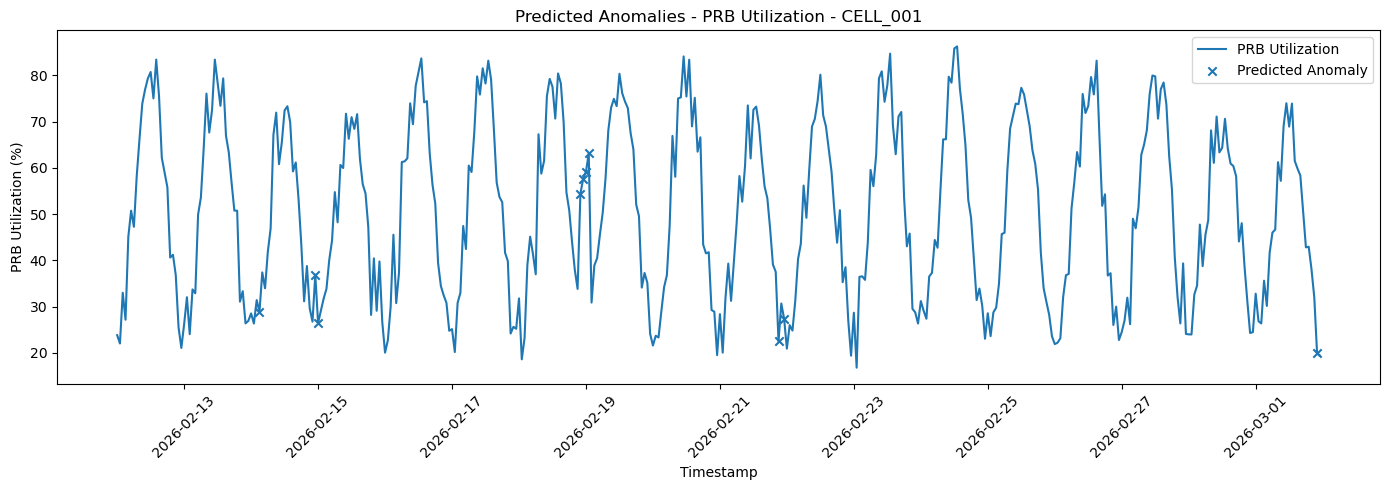

In [29]:
# Visualize predicted anomalies for one cell
sample_cell = "CELL_001"

plot_df = test_df[test_df["cell_id"] == sample_cell].copy()

plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], plot_df["prb_utilization"], label="PRB Utilization")

plt.scatter(
    plot_df.loc[plot_df["predicted_anomaly"] == 1, "timestamp"],
    plot_df.loc[plot_df["predicted_anomaly"] == 1, "prb_utilization"],
    marker="x",
    label="Predicted Anomaly"
)

plt.title(f"Predicted Anomalies - PRB Utilization - {sample_cell}")
plt.xlabel("Timestamp")
plt.ylabel("PRB Utilization (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

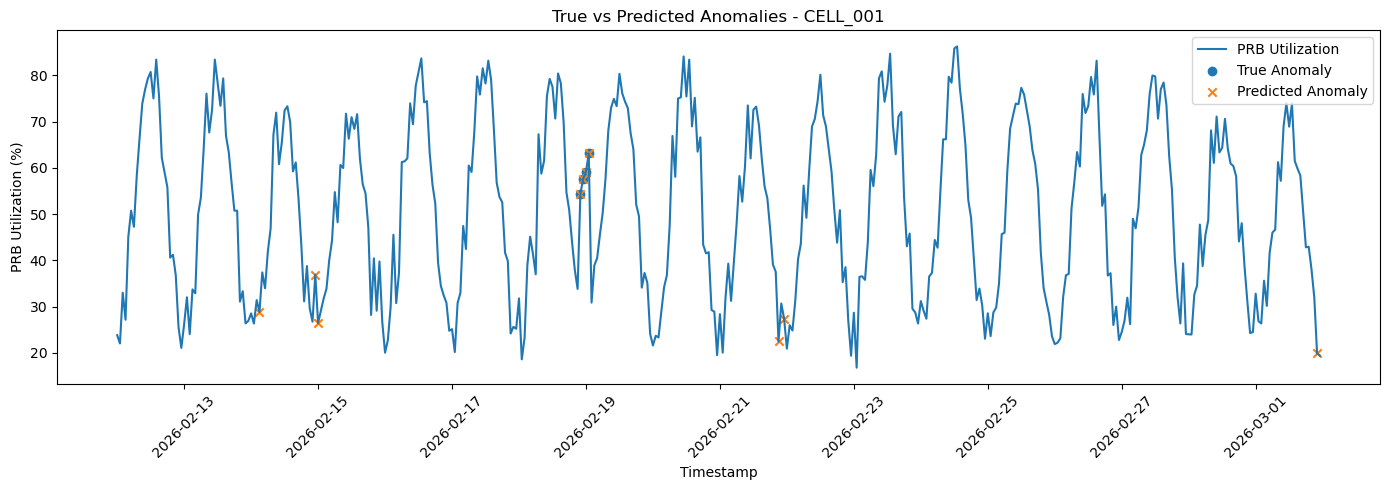

In [31]:
# Compare true vs predicted anomalies
plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], plot_df["prb_utilization"], label="PRB Utilization")

plt.scatter(
    plot_df.loc[plot_df["anomaly_label"] == 1, "timestamp"],
    plot_df.loc[plot_df["anomaly_label"] == 1, "prb_utilization"],
    marker="o",
    label="True Anomaly"
)

plt.scatter(
    plot_df.loc[plot_df["predicted_anomaly"] == 1, "timestamp"],
    plot_df.loc[plot_df["predicted_anomaly"] == 1, "prb_utilization"],
    marker="x",
    label="Predicted Anomaly"
)

plt.title(f"True vs Predicted Anomalies - {sample_cell}")
plt.xlabel("Timestamp")
plt.ylabel("PRB Utilization (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Tune the anomaly sensitivity
# Test different contamination values
# This will show how sensitive the model is.

results = []

contamination_values = [0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05]

for contamination in contamination_values:
    temp_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )
    
    temp_model.fit(X_train)
    
    raw_preds = temp_model.predict(X_test)
    temp_y_pred = np.where(raw_preds == -1, 1, 0)
    
    precision = precision_score(y_test, temp_y_pred)
    recall = recall_score(y_test, temp_y_pred)
    f1 = f1_score(y_test, temp_y_pred)
    
    results.append({
        "contamination": contamination,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "predicted_anomalies": temp_y_pred.sum()
    })

results_df = pd.DataFrame(results)

results_df

,contamination,precision,recall,f1_score,predicted_anomalies
0,0.015,0.976744,0.5250,0.682927,43
1,0.020,0.920635,0.7250,0.811189,63
2,0.025,0.812500,0.8125,0.812500,80
3,0.030,0.736842,0.8750,0.800000,95
4,0.035,0.576000,0.9000,0.702439,125
5,0.040,0.520548,0.9500,0.672566,146
6,0.050,0.439560,1.0000,0.610687,182


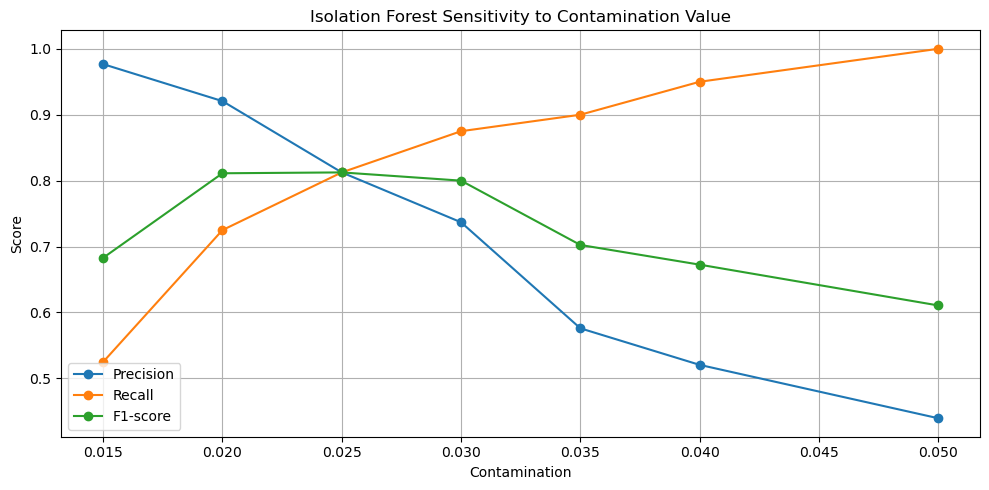

In [36]:
# Plot contamination tuning result

plt.figure(figsize=(10, 5))

plt.plot(results_df["contamination"], results_df["precision"], marker="o", label="Precision")
plt.plot(results_df["contamination"], results_df["recall"], marker="o", label="Recall")
plt.plot(results_df["contamination"], results_df["f1_score"], marker="o", label="F1-score")

plt.title("Isolation Forest Sensitivity to Contamination Value")
plt.xlabel("Contamination")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
# Select best value based on F1-score
best_row = results_df.loc[results_df["f1_score"].idxmax()]

print("Best contamination value:")
print(best_row)

Best contamination value:
contamination           0.0250
precision               0.8125
recall                  0.8125
f1_score                0.8125
predicted_anomalies    80.0000
Name: 2, dtype: float64


In [40]:
# Save tuning results
tuning_output_path = OUTPUTS_DIR / "local_model_tuning_results.csv"

results_df.to_csv(tuning_output_path, index=False)

print(f"Tuning results saved to: {tuning_output_path}")

Tuning results saved to: D:\aws-kpi-anomaly-detection\outputs\local_model_tuning_results.csv


In [ ]:
# Based on Results.df
# The best choice is:

#contamination = 0.025
#precision     = 0.8125
#recall        = 0.8125
#F1-score      = 0.8125

#This is the most balanced model. It detects anomalies well without creating too many false alarms.

#Why I recommend 0.025

#Compared to 0.030:

#0.030 → higher recall, but more false alarms
#0.025 → balanced precision and recall

#For a portfolio project, 0.025 is better because it shows a clean engineering decision:

#We tuned the anomaly sensitivity and selected the threshold that maximized F1-score while balancing false alarms and missed anomalies.

#This sounds very professional.

#So our final local baseline is:

#Model: Isolation Forest
#Contamination: 0.025
#F1-score: 0.8125
#Precision: 0.8125
#Recall: 0.8125

In [42]:
# Save the final local model output
# Train final selected model

final_contamination = 0.025

final_model = IsolationForest(
    n_estimators=200,
    contamination=final_contamination,
    random_state=42
)

final_model.fit(X_train)

final_raw_preds = final_model.predict(X_test)
final_y_pred = np.where(final_raw_preds == -1, 1, 0)

test_df["final_predicted_anomaly"] = final_y_pred
test_df["final_anomaly_score"] = -final_model.decision_function(X_test)

print("Final model trained successfully.")

Final model trained successfully.


In [44]:
# Final evaluation

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, final_y_pred))

print("\nFinal Classification Report:")
print(classification_report(y_test, final_y_pred, target_names=["Normal", "Anomaly"]))

final_precision = precision_score(y_test, final_y_pred)
final_recall = recall_score(y_test, final_y_pred)
final_f1 = f1_score(y_test, final_y_pred)

print("Final Precision:", round(final_precision, 3))
print("Final Recall:", round(final_recall, 3))
print("Final F1-score:", round(final_f1, 3))

Final Confusion Matrix:
[[3361   15]
 [  15   65]]

Final Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3376
     Anomaly       0.81      0.81      0.81        80

    accuracy                           0.99      3456
   macro avg       0.90      0.90      0.90      3456
weighted avg       0.99      0.99      0.99      3456

Final Precision: 0.812
Final Recall: 0.812
Final F1-score: 0.812


In [46]:
# Save final predictions

final_output_path = OUTPUTS_DIR / "final_local_anomaly_predictions.csv"

test_df.to_csv(final_output_path, index=False)

print(f"Final predictions saved to: {final_output_path}")

Final predictions saved to: D:\aws-kpi-anomaly-detection\outputs\final_local_anomaly_predictions.csv


In [48]:
# Save final model and scaler

import joblib

model_path = OUTPUTS_DIR / "final_isolation_forest_model.joblib"
scaler_path = OUTPUTS_DIR / "standard_scaler.joblib"

joblib.dump(final_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: D:\aws-kpi-anomaly-detection\outputs\final_isolation_forest_model.joblib
Scaler saved to: D:\aws-kpi-anomaly-detection\outputs\standard_scaler.joblib


In [50]:
# This gives us a proper local ML pipeline:

# data → preprocessing → scaling → model training → prediction → evaluation → saved model

# That is already a real AI/ML project foundation.